## <b>Gold price prediction using ML</b>

### Data collection
conclusion:
dataset contains 2290 rows and 6 columns
dataset dont have null values

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
#Load Dataset
df2=pd.read_csv("gold_model_dataset_2015_2025.csv")

EDA

In [3]:
df2.shape

(2290, 6)

In [4]:
df2.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
df2['Date']=pd.to_datetime(df2.Date,errors='coerce') 

In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [7]:
datasets = [
    (df2, 'df2 (2015-2025)')
]
print("SUMMARY STATISTICS")
print("="*60)
for df, title in datasets:
    print(f"\n{title}:")
    print(f"  Mean:   ${df['USO'].mean():.2f}")
    print(f"  Median: ${df['USO'].median():.2f}")
    print(f"  Std:    ${df['USO'].std():.2f}")
    print(f"  Min:    ${df['USO'].min():.2f}")
    print(f"  Max:    ${df['USO'].max():.2f}")
    print(f"  Range:  ${df['USO'].max() - df['USO'].min():.2f}")

SUMMARY STATISTICS

df2 (2015-2025):
  Mean:   $31.84
  Median: $33.87
  Std:    $19.52
  Min:    $7.96
  Max:    $117.48
  Range:  $109.52


In [8]:
df2.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


In [9]:
df2=df2.dropna()

In [10]:
df2.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


In [11]:
df2.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [12]:
df2['USO']=df2['USO'].round(2)

In [13]:
df2.duplicated(subset=['Date'], keep=False).sum()

0

In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


### Data Visualization

*Correlation:*
1. Positive Correlation
2. Negative Correlation

In [15]:
correlation = df.drop('Date', axis=1).corr()

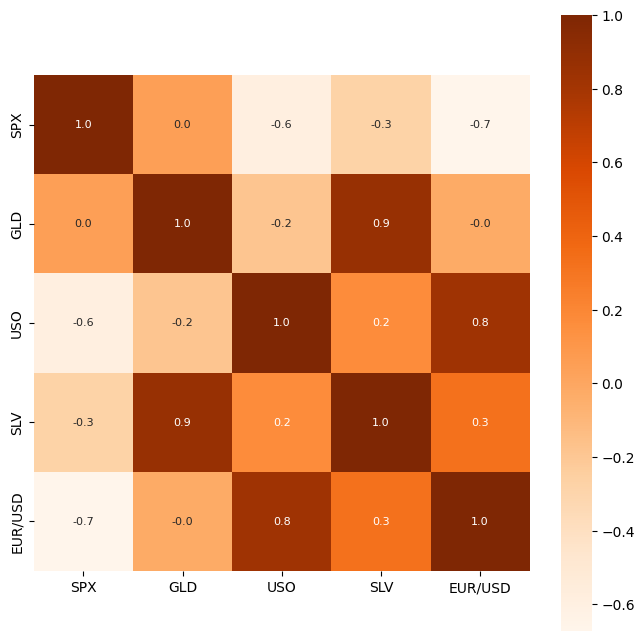

In [16]:
#constructing heatmap to understand correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar=True, square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Oranges')
plt.show()

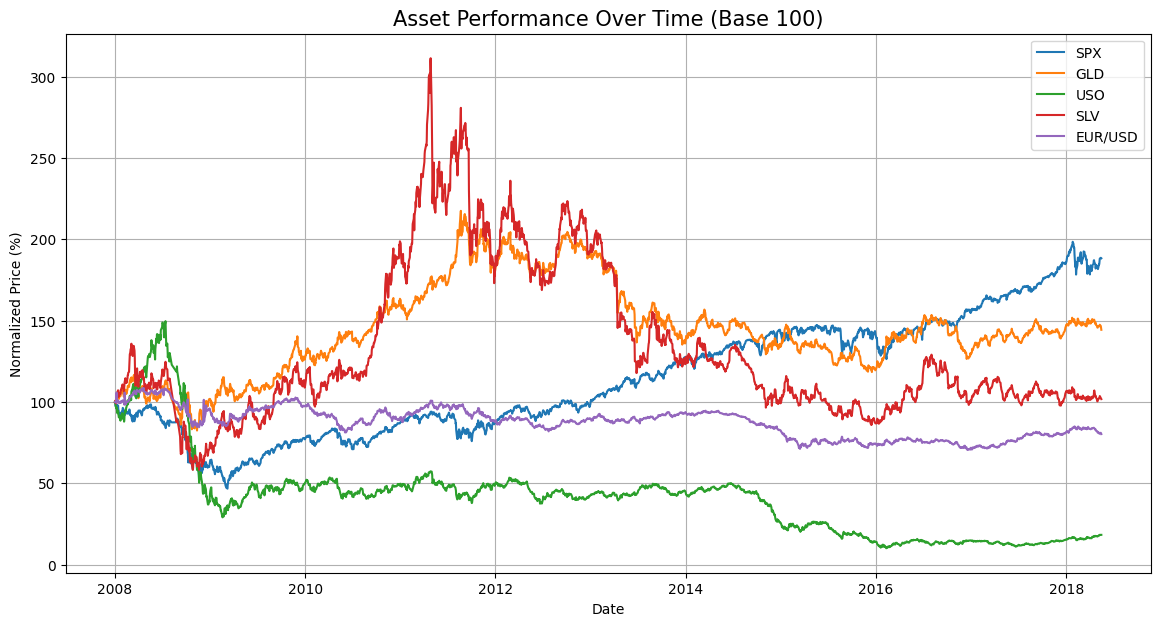

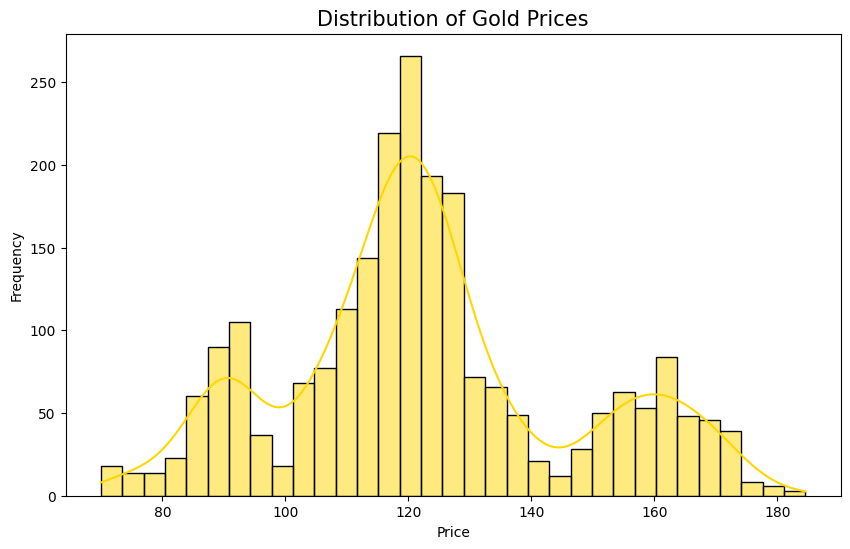

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Time Series Plot (Normalized to Base 100 for comparison)
plt.figure(figsize=(14, 7))
cols_to_plot = ['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(df2['Date'], (df2[col] / df2[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()


# 3. Distribution of Gold (GLD) Prices
plt.figure(figsize=(10, 6))
sns.histplot(df2['GLD'], kde=True, color='gold')
plt.title('Distribution of Gold Prices', fontsize=15)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

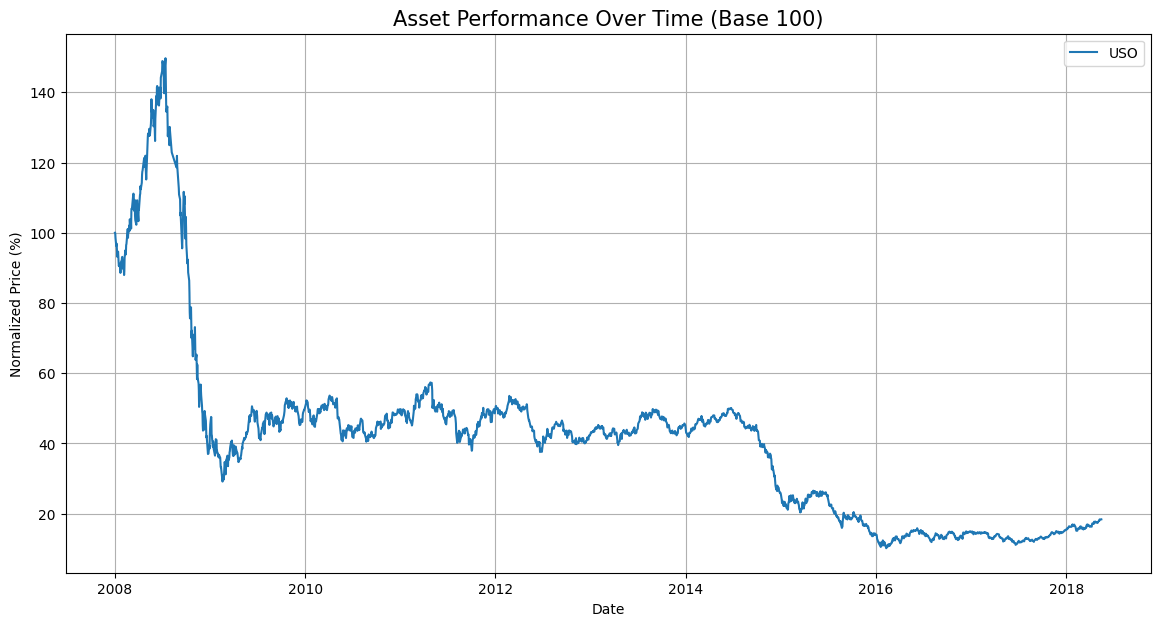

In [18]:
# 1. Time Series Plot (Normalized to Base 100 for comparison)
plt.figure(figsize=(14, 7))
cols_to_plot = ['USO']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(df2['Date'], (df2[col] / df2[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()


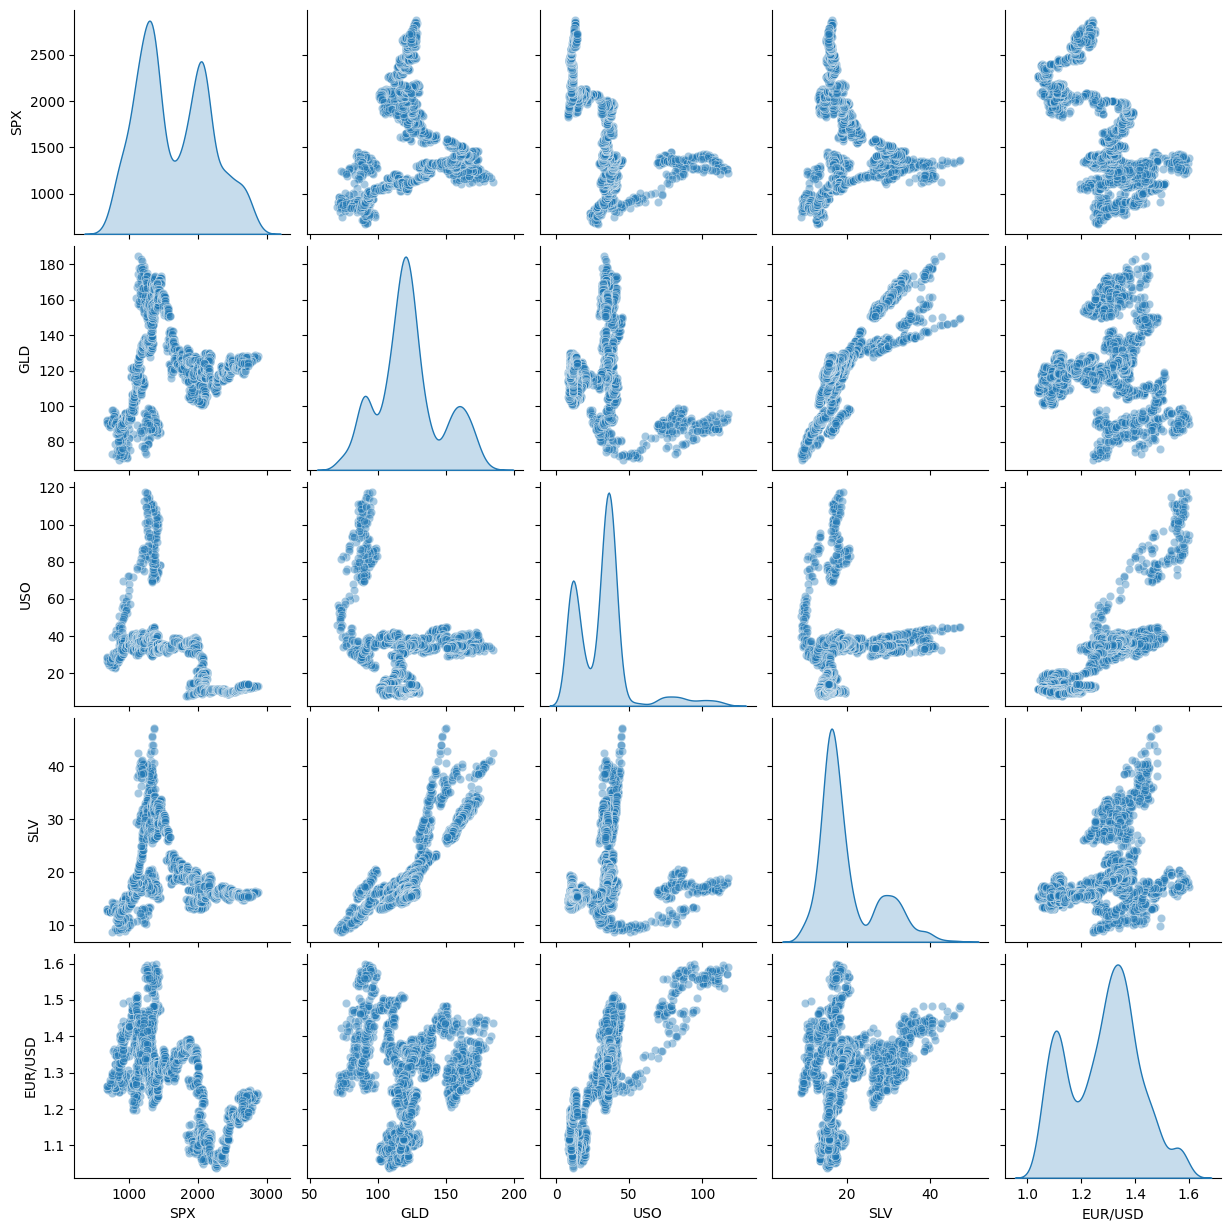

In [19]:
sns.pairplot(df2.drop(columns=['Date']), diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()

In [20]:
#correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


C:\Users\tanma\AppData\Local\Temp\ipykernel_29288\2989921348.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['GLD'])


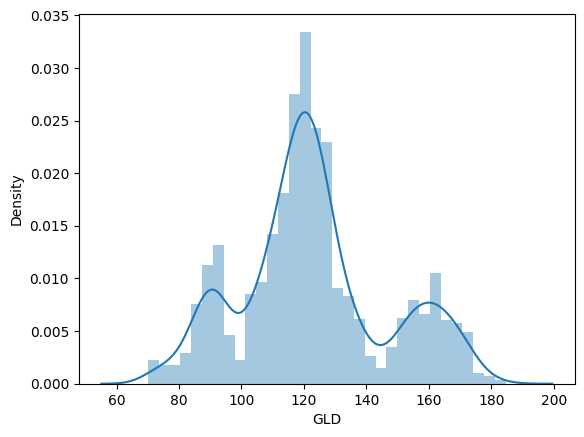

In [21]:
#cheacking the distribution of GLD values
sns.distplot(df2['GLD'])
plt.show()

### Data Splitting

In [22]:
X=df2.drop(['Date','GLD'],axis=1)
y=df2['GLD']

In [23]:
#Splittiing into Treining and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

### Model Selection

In [24]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)


RandomForestRegressor()

In [25]:
import joblib
joblib.dump(rf,"RandomeForest.joblib")

['RandomeForest.joblib']

### Model Evaluation

In [26]:
predict=rf.predict(X_test)

In [27]:
#R square error
error_score = metrics.r2_score(y_test, predict)

In [28]:
error_score

0.9886301645263529

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
lr=LinearRegression()

In [31]:
lr.fit(X_train,y_train)

LinearRegression()

In [32]:
lr_predict=lr.predict(X_test)

In [33]:
lr_error_score = metrics.r2_score(y_test, lr_predict)

In [34]:
lr_error_score

0.8657886415641138

In [35]:
lr.predict([[1420.329956,592.16,16.061001,1.4801]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-37.1824821])

In [36]:
#Real data
lr.predict([[6823.75,71.65,94.23,1.1733]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([384.4810977])

In [37]:
from sklearn.tree import DecisionTreeRegressor
dr=DecisionTreeRegressor()

In [38]:
dr.fit(X_train,y_train)

DecisionTreeRegressor()

In [39]:
dr_predict=dr.predict(X_test)

In [40]:
dr_error_score = metrics.r2_score(y_test, dr_predict)

In [41]:
dr_error_score

0.983679021462213

In [42]:
from xgboost import XGBRegressor
xg=XGBRegressor()
xg.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [43]:
xg_predict=xg.predict(X_test)

In [44]:
xg_error_score=metrics.r2_score(y_test, xg_predict)

In [45]:
xg_error_score

0.9873849231050468

In [46]:
xg.predict([[1416.25,594.0,16.280001,1.4869]])

array([85.93611], dtype=float32)

In [47]:
#Real data
xg.predict([[6823.75,71.65,94.23,1.1733]])

array([166.42902], dtype=float32)

In [48]:
#Real data
dr.predict([[6823.75,71.65,94.23,1.1733]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([171.720001])

In [49]:
dr.predict([[6823.75,573.2,94.23,1.1733]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([171.720001])

In [50]:
dr.predict([[6823.75,71.65,94.23,1.1733]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([171.720001])

In [51]:
lr.predict([[1416.25,594.0,16.280001,1.4869]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-37.04816856])

In [52]:
rf.predict([[1416.25,594.0,16.280001,1.4869]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([85.61049845])

In [53]:
#Real data
dr.predict([[6823.75,71.65,94.23,1.1733]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([171.720001])

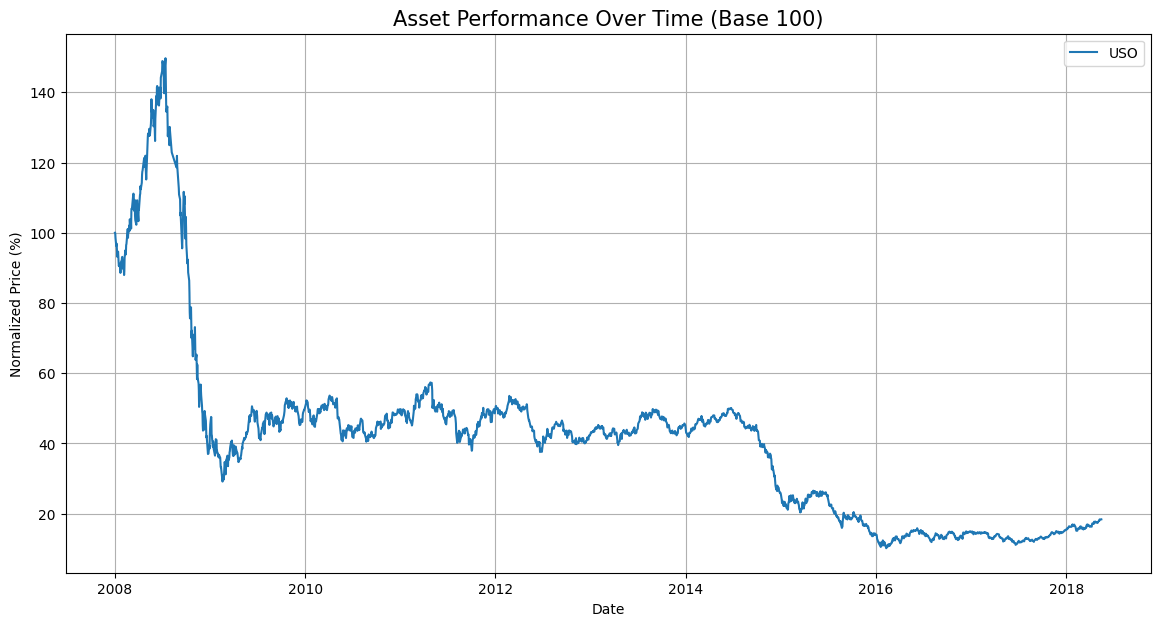

In [54]:
plt.figure(figsize=(14, 7))
cols_to_plot = ['USO']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(df2['Date'], (df2[col] / df2[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()